#### Supp Fig 4e

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import os
import scanpy as sc  
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib as mpl 
import cell2location 
import pandas as pd
import seaborn as sns  
import pandas as pd  
import random
import statsmodels.api as sm
pd.set_option('display.max_columns',400)
pd.set_option('display.max_categories',40)
# Set general parameters for publication-ready figures
plt.rcParams.update({
    'pdf.fonttype': 42,
    'font.family': 'Arial',  # Set font to Arial
    'font.size': 14,  # Set font size to at least 14
    'axes.labelsize': 14,  # Axes labels size
    'axes.titlesize': 16,  # Title size for axes
    'xtick.labelsize': 14,  # X-tick label size
    'ytick.labelsize': 14,  # Y-tick label size
    'legend.fontsize': 14,  # Legend font size
    'figure.titlesize': 16,  # Figure title size
    'lines.linewidth': 2,  # Line width for clarity
    'axes.linewidth': 1.5,  # Axis line width
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'text.color': 'black',  # Make sure text is black (not grey)
    'axes.labelcolor': 'black',  # Ensure axes labels are black
    'axes.edgecolor': 'black',  # Ensure edge of axes is black
    'xtick.color': 'black',  # Ensure X-tick marks are black
    'ytick.color': 'black',  # Ensure Y-tick marks are black
    'axes.titlepad': 20  # Padding for title

})

save_dir = "fig"
# Create the directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

boxprops=dict(edgecolor="black")
whiskerprops=dict(color="black")
capprops=dict(color='black')
medianprops=dict(color='black')



In [3]:
[
    d for d in os.listdir("./matt_detailed_annotation") 
    if os.path.isdir(f"./matt_detailed_annotation/{d}") and d[0].isdigit()
        ] + ["a"]

['22_50637_A1',
 '06_30914_A1',
 '16_46257_A1',
 '24_27523_C5',
 '08_38774_B2',
 '21_24095_A3',
 '18_57617_A1',
 'a']

In [4]:
import os

dirs = [
    d for d in os.listdir("./matt_detailed_annotation") 
    if os.path.isdir(f"./matt_detailed_annotation/{d}") and d[0].isdigit()
        ] + [
            d for d in os.listdir("./matt_detailed_annotation") 
    if os.path.isdir(f"./matt_detailed_annotation/{d}") and d[0].isdigit()
    ]
dirs

['22_50637_A1',
 '06_30914_A1',
 '16_46257_A1',
 '24_27523_C5',
 '08_38774_B2',
 '21_24095_A3',
 '18_57617_A1',
 '22_50637_A1',
 '06_30914_A1',
 '16_46257_A1',
 '24_27523_C5',
 '08_38774_B2',
 '21_24095_A3',
 '18_57617_A1']

In [5]:
adata_vis = sc.read_h5ad("/Users/jk/Documents/Lab2/visium/python_analysis/local_401/nmf/ann_finest_level/nfact12/h5ad/adata_vis_assigned_cell_types_nfact12_assigned_factors_log_minmax.h5ad")


In [6]:
adata_vis.obs


,in_tissue,array_row,array_col,library_id,alignment,desired_rc,actual_rc,xmin,xmax,ymin,ymax,hpx,vpx,slide,area,date,cytassist_ver,seq_batch,probe_date,probe_lot,probe_group,cond,cond_rep,rep,age,sex,bmi,packyears,FVC,DLCO,6MWD,outcome_long,tte_long,outcome_24m,tte_24m,lobe_lr,lobe,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,n_counts,n_genes,training_batch,AT0,AT1,AT2,AT2 proliferating,Adventitial fibroblasts,Alveolar Mph CCL3+,Alveolar Mph MT-positive,Alveolar Mph proliferating,Alveolar fibroblasts,Alveolar macrophages,B cells,Basal resting,CD4 T cells,CD8 T cells,Classical monocytes,Club (nasal),Club (non-nasal),DC1,DC2,Deuterosomal,EC aerocyte capillary,EC arterial,EC general capillary,EC venous pulmonary,EC venous systemic,Goblet (bronchial),Goblet (nasal),Goblet (subsegmental),Hillock-like,Interstitial Mph perivascular,Ionocyte,Lymphatic EC differentiating,Lymphatic EC mature,Mast cells,Mesothelium,Migratory DCs,Monocyte-derived Mph,Multiciliated (nasal),Multiciliated (non-nasal),Myofibroblasts,NK cells,Neuroendocrine,Non-classical monocytes,Peribronchial fibroblasts,Pericytes,Plasma cells,Plasmacytoid DCs,SM activated stress response,SMG duct,Smooth muscle,Smooth muscle FAM83D+,Subpleural fibroblasts,Suprabasal,T cells proliferating,Unknown,pre-TB secretory,cell_type_assigned,mean_nUMI_factorsfact_0,mean_nUMI_factorsfact_1,mean_nUMI_factorsfact_2,mean_nUMI_factorsfact_3,mean_nUMI_factorsfact_4,mean_nUMI_factorsfact_5,mean_nUMI_factorsfact_6,mean_nUMI_factorsfact_7,mean_nUMI_factorsfact_8,mean_nUMI_factorsfact_9,mean_nUMI_factorsfact_10,mean_nUMI_factorsfact_11,ATI/Endo,Perib. FB,Airway,B,Alv. macro,Alv. FB/immune,Adv. FB,Macro,Immune,SMC,ATII,Plasma,ATI/Endo_log_minmax,Perib. FB_log_minmax,Airway_log_minmax,B_log_minmax,Alv. macro_log_minmax,Alv. FB/immune_log_minmax,Adv. FB_log_minmax,Macro_log_minmax,Immune_log_minmax,SMC_log_minmax,ATII_log_minmax,Plasma_log_minmax,factor_assigned
AACACGTGCATCGCAC-1-18_57617_A1,1.0,76.0,22.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,3961,8.284504,7804.0,8.962520,31.765761,35.212711,39.928242,49.410559,629.0,6.445720,8.059970,0.0,0.0,0.0,0.0,0.0,0.0,7804.0,3961,0,0.000967,0.000081,0.000023,0.000279,0.234594,0.009023,0.003434,0.045472,0.387183,0.001108,3.730742,0.001663,0.065855,0.019768,0.004821,0.127872,0.000417,0.008481,0.040385,0.010641,0.001719,0.002331,0.000529,0.001759,0.004936,0.001933,0.000464,0.042375,0.002770,0.058909,0.003027,0.003101,0.008538,0.003847,0.000322,0.044897,0.017594,0.026567,0.000907,0.003966,0.016523,0.092378,0.008129,0.037726,0.014092,0.968134,0.362111,0.025284,0.008943,0.038652,0.060598,0.231837,0.004889,0.044583,0.001354,0.000324,B cells,0.000000,0.000000,0.000000,3.568719,0.000000,2.327530,0.081827,0.000000,0.780313,0.000000,0.000000,1.475469,0.000000,0.000000,0.000000,3.568719,0.000000,2.327530,0.081827,0.000000,0.780313,0.000000,0.000000,1.475469,0.000000,0.000000,0.000000,0.773084,0.000000,0.717544,0.502845,0.000000,0.620036,0.000000,0.000000,0.740151,B
AACACTTGGCAAGGAA-1-18_57617_A1,1.0,47.0,71.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,3322,8.108623,5412.0,8.596559,15.909091,20.842572,27.475979,40.742794,280.0,5.638355,5.173688,0.0,0.0,0.0,0.0,0.0,0.0,5412.0,3322,0,0.137828,0.802715,0.341800,0.009572,0.139944,0.039461,0.032829,0.186727,0.888112,0.481472,0.039227,0.013804,0.056936,0.042788,0.031012,0.009081,0.043570,0.023910,0.040213,0.001578,1.365678,0.136504,0.618607,0.156473,0.098999,0.008318,0.010266

In [7]:
adata_sub = adata_vis[adata_vis.obs['library_id'].isin(dirs)].copy()

In [8]:
adata_sub.shape

(26782, 16959)

In [9]:
annos =['Airway',
 'FF',
 'Fibrosis',
 'Granuloma',
 'Inflammatory',
 'Lymphoid',
 'Uninvolved']


In [10]:
for anno in annos:
    adata_sub.obs[f"path_{anno}"] = 0


In [11]:
dirs

['22_50637_A1',
 '06_30914_A1',
 '16_46257_A1',
 '24_27523_C5',
 '08_38774_B2',
 '21_24095_A3',
 '18_57617_A1',
 '22_50637_A1',
 '06_30914_A1',
 '16_46257_A1',
 '24_27523_C5',
 '08_38774_B2',
 '21_24095_A3',
 '18_57617_A1']

In [12]:
from pathlib import Path
for library_id in dirs:
    

    for anno in annos:
        f = Path("symlink") / f"{library_id}_{anno}.npy"
        if not f.exists():
            continue

        idx = np.load(f, allow_pickle=True)

        col = f"path_{anno}"

        # intersection protects against stale / mismatched indices
        idx = adata_sub.obs.index.intersection(idx)

        adata_sub.obs.loc[idx, col] = 1


In [13]:
adata_sub.obs

,in_tissue,array_row,array_col,library_id,alignment,desired_rc,actual_rc,xmin,xmax,ymin,ymax,hpx,vpx,slide,area,date,cytassist_ver,seq_batch,probe_date,probe_lot,probe_group,cond,cond_rep,rep,age,sex,bmi,packyears,FVC,DLCO,6MWD,outcome_long,tte_long,outcome_24m,tte_24m,lobe_lr,lobe,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,n_counts,n_genes,training_batch,AT0,AT1,AT2,AT2 proliferating,Adventitial fibroblasts,Alveolar Mph CCL3+,Alveolar Mph MT-positive,Alveolar Mph proliferating,Alveolar fibroblasts,Alveolar macrophages,B cells,Basal resting,CD4 T cells,CD8 T cells,Classical monocytes,Club (nasal),Club (non-nasal),DC1,DC2,Deuterosomal,EC aerocyte capillary,EC arterial,EC general capillary,EC venous pulmonary,EC venous systemic,Goblet (bronchial),Goblet (nasal),Goblet (subsegmental),Hillock-like,Interstitial Mph perivascular,Ionocyte,Lymphatic EC differentiating,Lymphatic EC mature,Mast cells,Mesothelium,Migratory DCs,Monocyte-derived Mph,Multiciliated (nasal),Multiciliated (non-nasal),Myofibroblasts,NK cells,Neuroendocrine,Non-classical monocytes,Peribronchial fibroblasts,Pericytes,Plasma cells,Plasmacytoid DCs,SM activated stress response,SMG duct,Smooth muscle,Smooth muscle FAM83D+,Subpleural fibroblasts,Suprabasal,T cells proliferating,Unknown,pre-TB secretory,cell_type_assigned,mean_nUMI_factorsfact_0,mean_nUMI_factorsfact_1,mean_nUMI_factorsfact_2,mean_nUMI_factorsfact_3,mean_nUMI_factorsfact_4,mean_nUMI_factorsfact_5,mean_nUMI_factorsfact_6,mean_nUMI_factorsfact_7,mean_nUMI_factorsfact_8,mean_nUMI_factorsfact_9,mean_nUMI_factorsfact_10,mean_nUMI_factorsfact_11,ATI/Endo,Perib. FB,Airway,B,Alv. macro,Alv. FB/immune,Adv. FB,Macro,Immune,SMC,ATII,Plasma,ATI/Endo_log_minmax,Perib. FB_log_minmax,Airway_log_minmax,B_log_minmax,Alv. macro_log_minmax,Alv. FB/immune_log_minmax,Adv. FB_log_minmax,Macro_log_minmax,Immune_log_minmax,SMC_log_minmax,ATII_log_minmax,Plasma_log_minmax,factor_assigned,path_Airway,path_FF,path_Fibrosis,path_Granuloma,path_Inflammatory,path_Lymphoid,path_Uninvolved
AACACGTGCATCGCAC-1-18_57617_A1,1.0,76.0,22.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,3961,8.284504,7804.0,8.962520,31.765761,35.212711,39.928242,49.410559,629.0,6.445720,8.059970,0.0,0.0,0.0,0.0,0.0,0.0,7804.0,3961,0,0.000967,0.000081,0.000023,0.000279,0.234594,0.009023,0.003434,0.045472,0.387183,0.001108,3.730742,0.001663,0.065855,0.019768,0.004821,0.127872,0.000417,0.008481,0.040385,0.010641,0.001719,0.002331,0.000529,0.001759,0.004936,0.001933,0.000464,0.042375,0.002770,0.058909,0.003027,0.003101,0.008538,0.003847,0.000322,0.044897,0.017594,0.026567,0.000907,0.003966,0.016523,0.092378,0.008129,0.037726,0.014092,0.968134,0.362111,0.025284,0.008943,0.038652,0.060598,0.231837,0.004889,0.044583,0.001354,0.000324,B cells,0.000000,0.000000,0.000000,3.568719,0.000000,2.327530,0.081827,0.000000,0.780313,0.000000,0.000000,1.475469,0.000000,0.000000,0.000000,3.568719,0.000000,2.327530,0.081827,0.000000,0.780313,0.000000,0.000000,1.475469,0.000000,0.000000,0.000000,0.773084,0.000000,0.717544,0.502845,0.000000,0.620036,0.000000,0.000000,0.740151,B,0,0,0,0,0,0,0
AACACTTGGCAAGGAA-1-18_57617_A1,1.0,47.0,71.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,3322,8.108623,5412.0,8.596559,15.909091,20.842572,27.475979,40.742794,280.0,5.638355,5.173688,0.0,0.0,0.0,0.0,0.0,0.0,5412.0,3322,0,0.137828,0.802715,0.341800,0.009572,0.139944,0.039461,0.032829,0.186727,0.888112,0.481472,0.039227,0.013804,0.056936,0.042788,0.031

In [14]:
niche_order = ["ATI/Endo", "Alv. FB/immune", "Plasma", "SMC", "ATII", "Immune", "Airway", "Adv. FB", "Perib. FB", "Alv. macro", "Macro" , "B"]

In [15]:
niche_order_log_minmax = [f"{x}_log_minmax" for x in niche_order]

In [16]:
import pandas as pd
import numpy as np

cell_ab = adata_sub.obs.loc[:, niche_order_log_minmax]
cell_ab = pd.DataFrame(
    cell_ab,
    index=adata_sub.obs.index,
    columns=niche_order_log_minmax
)


In [17]:
cell_ab

,ATI/Endo_log_minmax,Alv. FB/immune_log_minmax,Plasma_log_minmax,SMC_log_minmax,ATII_log_minmax,Immune_log_minmax,Airway_log_minmax,Adv. FB_log_minmax,Perib. FB_log_minmax,Alv. macro_log_minmax,Macro_log_minmax,B_log_minmax
AACACGTGCATCGCAC-1-18_57617_A1,0.000000,0.717544,0.740151,0.000000,0.000000,0.620036,0.000000,0.502845,0.000000,0.000000,0.000000,0.773084
AACACTTGGCAAGGAA-1-18_57617_A1,0.837606,0.749843,0.000000,0.590861,0.000000,0.000000,0.718571,0.000000,0.000000,0.569461,0.000000,0.000000
AACAGGATTCATAGTT-1-18_57617_A1,0.831651,0.506089,0.000000,0.181447,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
AACAGGTTCACCGAAG-1-18_57617_A1,0.805631,0.000000,0.000000,0.252892,0.000000,0.607305,0.000000,0.000000,0.000000,0.000000,0.000000,0.415806
AACAGTCAGGCTCCGC-1-18_57617_A1,0.771889,0.000000,0.000000,0.451357,0.645817,0.522992,0.633608,0.000000,0.735721,0.601415,0.788568,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
TGTTGGAACCTTCCGC-1-21_24095_A3,0.820281,0.655865,0.000000,0.000000,0.635747,0.820062,0.000000,0.685440,0.673648,0.000000,0.000000,0.000000
TGTTGGAACGAGGTCA-1-21_24095_A3,0.873473,0.823658,0.000000,0.000000,0.761881,0.569522,0.000000,0.000000,0.751764,0.000000,0.000000,0.000000
TGTTGGAAGCTCGGTA-1-21_24095_A3,0.827746,0.777675,0.000000,0.501720,0.000000,0.000000,0.000000,0.000000,0.706737,0.000000,0.000000,0.000000
TGTTGGATGGACTTCT-1-21_24095_A3,0.622495,0.920017,0.000000,0.626198,0.000000,0.761855,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [18]:
rows = []

path_cols = [c for c in adata_sub.obs.columns if c.startswith("path_")]

for path in path_cols:
    mask = adata_sub.obs[path].astype(bool)
    n_spots = mask.sum()

    if n_spots == 0:
        continue

    sub = cell_ab.loc[mask]

    for niche in cell_ab.columns:
        rows.append({
            "pathology": path.replace("path_", ""),
            "niche": niche,
            "mean_norm_abundance": sub[niche].mean().astype(float),
            "frac_spots_above": (sub[niche] > 0.7).mean().astype(float), # what prop of spots have norm abundance > 0.7?
            #"n_spots": n_spots,
        })

df = pd.DataFrame(rows)


In [19]:
rows

[{'pathology': 'Airway',
  'niche': 'ATI/Endo_log_minmax',
  'mean_norm_abundance': 0.5113661724273271,
  'frac_spots_above': 0.35294117647058826},
 {'pathology': 'Airway',
  'niche': 'Alv. FB/immune_log_minmax',
  'mean_norm_abundance': 0.6489395088589023,
  'frac_spots_above': 0.453781512605042},
 {'pathology': 'Airway',
  'niche': 'Plasma_log_minmax',
  'mean_norm_abundance': 0.10619643961062039,
  'frac_spots_above': 0.008403361344537815},
 {'pathology': 'Airway',
  'niche': 'SMC_log_minmax',
  'mean_norm_abundance': 0.37966973873975746,
  'frac_spots_above': 0.14285714285714285},
 {'pathology': 'Airway',
  'niche': 'ATII_log_minmax',
  'mean_norm_abundance': 0.13291546574749805,
  'frac_spots_above': 0.04201680672268908},
 {'pathology': 'Airway',
  'niche': 'Immune_log_minmax',
  'mean_norm_abundance': 0.5639362125185425,
  'frac_spots_above': 0.11764705882352941},
 {'pathology': 'Airway',
  'niche': 'Airway_log_minmax',
  'mean_norm_abundance': 0.8196704274258823,
  'frac_spots_a

In [20]:
df

,pathology,niche,mean_norm_abundance,frac_spots_above
0,Airway,ATI/Endo_log_minmax,0.511366,0.352941
1,Airway,Alv. FB/immune_log_minmax,0.648940,0.453782
2,Airway,Plasma_log_minmax,0.106196,0.008403
3,Airway,SMC_log_minmax,0.379670,0.142857
4,Airway,ATII_log_minmax,0.132915,0.042017
...,...,...,...,...
79,Uninvolved,Adv. FB_log_minmax,0.066191,0.028285
80,Uninvolved,Perib. FB_log_minmax,0.144296,0.043187
81,Uninvolved,Alv. macro_log_minmax,0.227717,0.074513
82,Uninvolved,Macro_log_minmax,0.104069,0.036344


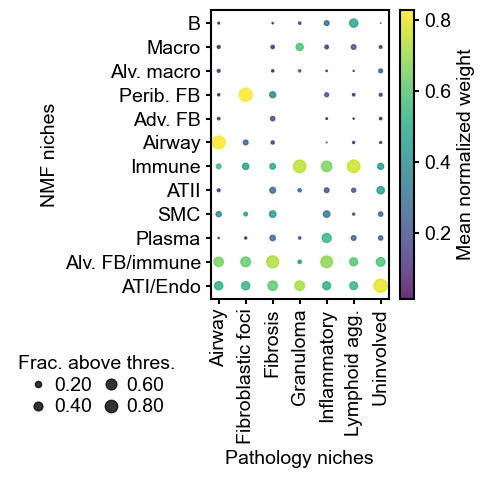

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize = (5, 5))
sc = ax.scatter(
    x=df["pathology"],
    y=df["niche"],
    s=df["frac_spots_above"]*100,    
    c=df["mean_norm_abundance"],             # continuous color
    cmap="viridis",
    alpha=0.8,
)


kw = dict(prop="sizes", num=6, fmt="{x:.2f}",
          func=lambda s: s/100)
legend2 = ax.legend(*sc.legend_elements(**kw),
                    loc="right",
                    bbox_to_anchor = (-0.1, -0.3), frameon =False, ncol = 2,
                    handlelength=1,       # shorter line for marker
                    handletextpad=0.3,    # distance between marker and label
                    columnspacing=0.5,    # space between columns
                    labelspacing=0.2,
                    title="Frac. above thres.")

plt.xticks(rotation=90)
plt.xlabel("Pathology niches")
plt.gca().set_xticklabels(['Airway', "Fibroblastic foci", "Fibrosis", "Granuloma","Inflammatory", "Lymphoid agg.", "Uninvolved"])
plt.ylabel("NMF niches")
# Get current tick labels
yticks = [tick.get_text() for tick in plt.gca().get_yticklabels()]

# Remove suffix
new_labels = [label.replace("_log_minmax", "") for label in yticks]
 
# Set updated labels
plt.gca().set_yticklabels(new_labels)


plt.colorbar(sc, label="Mean normalized weight")


plt.tight_layout()
plt.savefig("fig/dotplot_aggregated.pdf", transparent = True)

plt.show()
